# Commit impact scores

Computes the per-commit impact heuristic from `model/README.md` (Section 10) on the real ETL extract.

**How to run** (from `notebooks/`):

```bash
uv sync
uv run jupyter lab commit_impact.ipynb
```

Pick the kernel from `notebooks/.venv`. Input rows are validated with `github_etl.schemas.FinalCommitSchema` — the same class the pipeline writes against, not a local copy.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from github_etl.schemas import FINAL_COLUMNS, FinalCommitSchema
from pandera.pandas import Field
from pandera.typing import Series

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 140)

## 0. Load and validate

Rows come from `github_etl/data/contributor_commits.parquet`.
Parquet round-trips list columns as NumPy arrays, so we coerce them back to Python `list` before `FinalCommitSchema`'s list checks.

In [2]:
LIST_COLS = [
    "branch",
    "pr",
    "pr_state",
    "number_of_comments_on_pr",
    "connected_issue",
    "number_of_comments_on_connected_issue",
]


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    marker = Path("github_etl") / "src" / "github_etl" / "schemas.py"
    for candidate in (here, *here.parents):
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(
        "Could not find github_etl/src/github_etl/schemas.py. "
        "Run Jupyter from the repo root or notebooks/."
    )


def to_python_list(value: object) -> list:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, list):
        return value
    return list(value)


REPO_ROOT = find_repo_root()
DATA_PATH = REPO_ROOT / "github_etl" / "data" / "contributor_commits.parquet"
raw = pd.read_parquet(DATA_PATH)
for col in LIST_COLS:
    raw[col] = raw[col].map(to_python_list)
raw["committed_at"] = pd.to_datetime(raw["committed_at"], utc=True)
commits = FinalCommitSchema.validate(raw[FINAL_COLUMNS])

print(f"loaded {DATA_PATH}")
print(f"schema: {FinalCommitSchema.__module__}.{FinalCommitSchema.__name__}")
print(f"rows={len(commits):,}  contributors={commits['contributor'].nunique(dropna=True)}")
print(
    "window: "
    f"{commits['committed_at'].min().date()} → {commits['committed_at'].max().date()}"
)
commits.head()

loaded /Users/steffen/Documents/posthog_contributor_impact/github_etl/data/contributor_commits.parquet
schema: github_etl.schemas.FinalCommitSchema
rows=13,202  contributors=210
window: 2026-05-20 → 2026-08-18


,commit_id,committed_at,contributor,branch,pr,pr_state,number_of_comments_on_pr,has_pr_been_merged_into_main,connected_issue,number_of_comments_on_connected_issue
0,00036d38ae536175d63455c0d0055affe43250cc,2026-07-27 11:48:12+00:00,Gilbert09,[posthog-code/fix-shopify-401-non-retryable],[73802],[MERGED],[2],True,[],[]
1,00069ca66a70af631a6008c3eb7fa4eae1d5c87f,2026-06-04 14:58:32+00:00,MattPua,[06-03-feat_dashboards_show_widget_placeholders_on_shared_dashboards],[61416],[MERGED],[19],True,[],[]
2,000d0abdab8c45eb5456741c68a361562a5b8fc8,2026-06-17 19:55:16+00:00,TueHaulund,[tue/replay-vision-signals],[63224],[MERGED],[22],True,[],[]
3,0011a28f7a484a830ed03981c81a29830eeb7e51,2026-07-17 07:15:19+00:00,ablaszkiewicz,[posthog-code/error-tracking-widget-decouple-autocapture],[71608],[MERGED],[8],True,[],[]
4,00190e9730a80a958eb052c5803c42e0be1e3524,2026-08-13 15:46:22+00:00,nickbest-ph,[nick/personhog-merge-small-fixes],[82270],[MERGED],[7],True,[],[]


## 1. Score each commit

Additive heuristic from `model/README.md` §10. Each component is scaled to [0, 1] then multiplied by a weight (the maximum points that component can contribute):

| Component | Signal | Weight |
| --- | --- | ---: |
| Base | 1 | 1.0 |
| Landing | ladder *L* below | 3.0 |
| Review depth | *c*<sub>pr</sub> / (*c*<sub>pr</sub> + 4) | 2.0 |
| Issue attachment | 1 if ≥ 1 linked issue | 1.5 |
| Issue complexity | *c*<sub>iss</sub> / (*c*<sub>iss</sub> + 6) | 2.5 |

*c*<sub>pr</sub> is the **max** of `number_of_comments_on_pr`; *c*<sub>iss</sub> is the **sum** of `number_of_comments_on_connected_issue`.

Landing ladder *L*: merged into main → 1.00; `MERGED` but not main → 0.50; `OPEN` → 0.25; `CLOSED` or no PR → 0.00. With several PRs, take the best rung.

The scored frame is validated with `ScoredCommitSchema`, which **extends** `FinalCommitSchema` so the original ETL columns still have to pass the github_etl checks.

In [3]:
WEIGHT_BASE = 1.0
WEIGHT_LANDING = 3.0
WEIGHT_REVIEW = 2.0
WEIGHT_ATTACH = 1.5
WEIGHT_COMPLEXITY = 2.5
K_PR = 4.0
K_ISSUE = 6.0
LANDING_LADDER = {"MERGED": 0.5, "OPEN": 0.25, "CLOSED": 0.0}


def _is_missing(value: object) -> bool:
    if value is None:
        return True
    if isinstance(value, float) and pd.isna(value):
        return True
    if isinstance(value, str) and value.lower() == "nan":
        return True
    return False


def landing_level(merged_into_main: bool, states: list) -> float:
    if bool(merged_into_main):
        return 1.0
    best = 0.0
    for state in states:
        if _is_missing(state):
            continue
        best = max(best, LANDING_LADDER.get(str(state), 0.0))
    return best


def max_count(values: list) -> float:
    nums = [float(value) for value in values if not _is_missing(value)]
    return max(nums) if nums else 0.0


def sum_count(values: list) -> float:
    return float(sum(float(value) for value in values if not _is_missing(value)))


def saturate(count: float, half_life: float) -> float:
    return count / (count + half_life)


def score_commits(frame: pd.DataFrame) -> pd.DataFrame:
    scored = frame.copy()
    landing = [
        landing_level(merged, states)
        for merged, states in zip(
            scored["has_pr_been_merged_into_main"], scored["pr_state"], strict=True
        )
    ]
    c_pr = scored["number_of_comments_on_pr"].map(max_count)
    c_iss = scored["number_of_comments_on_connected_issue"].map(sum_count)
    attached = scored["connected_issue"].map(lambda values: 1.0 if len(values) else 0.0)
    review = c_pr.map(lambda count: saturate(count, K_PR))
    complexity = c_iss.map(lambda count: saturate(count, K_ISSUE))

    scored["landing"] = landing
    scored["c_pr"] = c_pr
    scored["c_iss"] = c_iss
    scored["attached"] = attached
    scored["review"] = review
    scored["complexity"] = complexity
    scored["landing_points"] = WEIGHT_LANDING * scored["landing"]
    scored["review_points"] = WEIGHT_REVIEW * scored["review"]
    scored["attach_points"] = WEIGHT_ATTACH * scored["attached"]
    scored["complexity_points"] = WEIGHT_COMPLEXITY * scored["complexity"]
    scored["impact"] = (
        WEIGHT_BASE
        + scored["landing_points"]
        + scored["review_points"]
        + scored["attach_points"]
        + scored["complexity_points"]
    )
    return scored


class ScoredCommitSchema(FinalCommitSchema):
    """FinalCommitSchema plus the Section 10 score columns."""

    landing: Series[float] = Field(ge=0.0, le=1.0)
    c_pr: Series[float] = Field(ge=0.0)
    c_iss: Series[float] = Field(ge=0.0)
    attached: Series[float] = Field(ge=0.0, le=1.0)
    review: Series[float] = Field(ge=0.0, le=1.0)
    complexity: Series[float] = Field(ge=0.0, le=1.0)
    landing_points: Series[float] = Field(ge=0.0, le=WEIGHT_LANDING)
    review_points: Series[float] = Field(ge=0.0, le=WEIGHT_REVIEW)
    attach_points: Series[float] = Field(ge=0.0, le=WEIGHT_ATTACH)
    complexity_points: Series[float] = Field(ge=0.0, le=WEIGHT_COMPLEXITY)
    impact: Series[float] = Field(ge=WEIGHT_BASE, le=10.0)

    class Config:
        coerce = True
        strict = True


scored = ScoredCommitSchema.validate(score_commits(commits))
assert list(scored.columns[: len(FINAL_COLUMNS)]) == FINAL_COLUMNS
print(scored["impact"].describe().round(3).to_string())
scored[["commit_id", "contributor", "landing_points", "review_points", "attach_points", "complexity_points", "impact"]].head()

count    13202.000
mean         5.281
std          0.451
min          1.000
25%          5.111
50%          5.273
75%          5.467
max          8.784


,commit_id,contributor,landing_points,review_points,attach_points,complexity_points,impact
0,00036d38ae536175d63455c0d0055affe43250cc,Gilbert09,3.0,0.666667,0.0,0.0,4.666667
1,00069ca66a70af631a6008c3eb7fa4eae1d5c87f,MattPua,3.0,1.652174,0.0,0.0,5.652174
2,000d0abdab8c45eb5456741c68a361562a5b8fc8,TueHaulund,3.0,1.692308,0.0,0.0,5.692308
3,0011a28f7a484a830ed03981c81a29830eeb7e51,ablaszkiewicz,3.0,1.333333,0.0,0.0,5.333333
4,00190e9730a80a958eb052c5803c42e0be1e3524,nickbest-ph,3.0,1.272727,0.0,0.0,5.272727


## 2. Score mix

How much of each component's ceiling the extract actually uses. On this ETL window almost every commit is already on a PR merged into main, so landing is near its ceiling and issue attachment is rare.

In [4]:
components = pd.DataFrame(
    {
        "component": ["Base", "Landing", "Review depth", "Issue attachment", "Issue complexity"],
        "mean_points": [
            WEIGHT_BASE,
            scored["landing_points"].mean(),
            scored["review_points"].mean(),
            scored["attach_points"].mean(),
            scored["complexity_points"].mean(),
        ],
        "ceiling": [WEIGHT_BASE, WEIGHT_LANDING, WEIGHT_REVIEW, WEIGHT_ATTACH, WEIGHT_COMPLEXITY],
    }
)
components["share_of_ceiling"] = components["mean_points"] / components["ceiling"]
display(components.round(3))

print("landing ladder (L) counts:")
print(scored["landing"].value_counts().sort_index().to_string())
print(f"\nshare with a linked issue: {scored['attached'].mean():.3%}")

,component,mean_points,ceiling,share_of_ceiling
0,Base,1.000,1.0,1.000
1,Landing,2.989,3.0,0.996
2,Review depth,1.258,2.0,0.629
3,Issue attachment,0.029,1.5,0.019
4,Issue complexity,0.005,2.5,0.002


landing ladder (L) counts:
landing
0.0       27
0.5       41
1.0    13134

share with a linked issue: 1.924%


## 3. Commit scores by contributor

One box per contributor: the distribution of that person's **commit-level** impact scores.
Contributors are sorted **left to right** by descending mean score (the raw ȳ<sub>j</sub> that the hierarchical model later shrinks).
A box with no whiskers is usually someone with one or two commits — 49 people in this extract have a single commit.

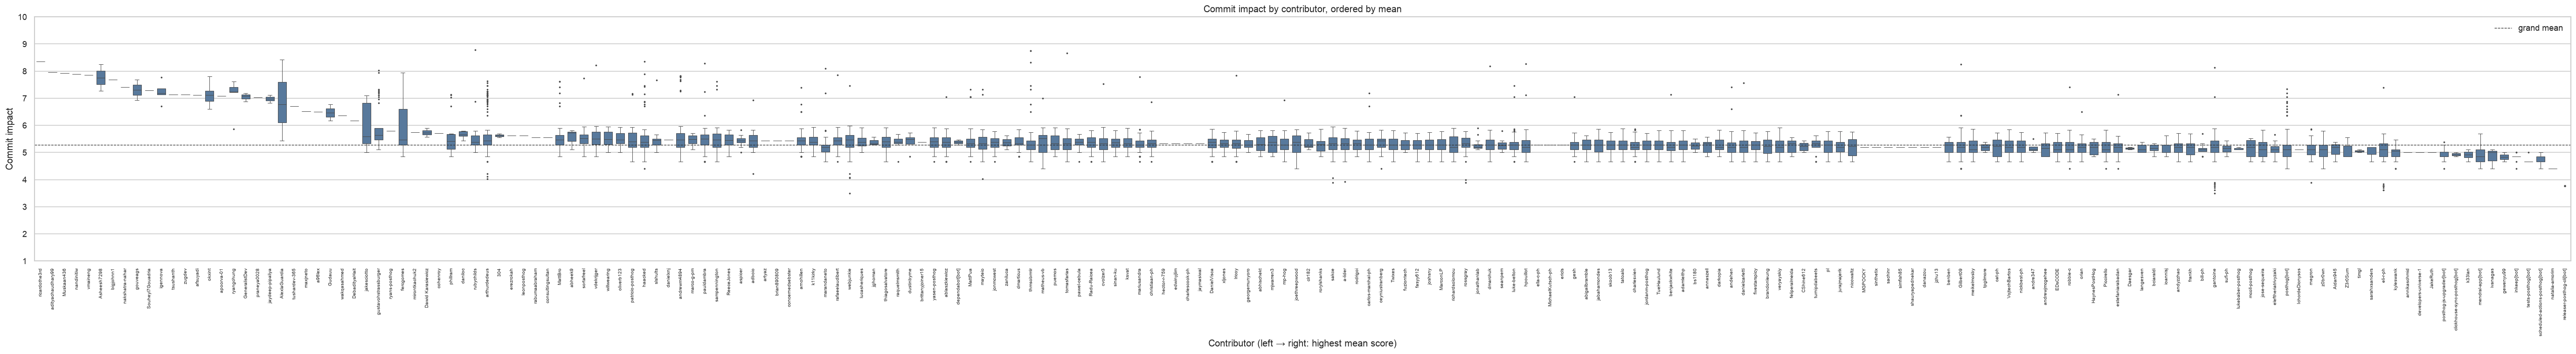

highest mean scores:


,n,mean,median,std
contributor,,,,
ricardothe3rd,1,8.357,8.357,NaN
adityachaudhary99,1,7.957,7.957,NaN
Muskaan436,1,7.929,7.929,NaN
nandinitiw,1,7.885,7.885,NaN
vmaineng,1,7.861,7.861,NaN
Asheesh7298,2,7.760,7.760,0.701
bigjohnn1,1,7.681,7.681,NaN
nakshatra-nahar,1,7.413,7.413,NaN
gouveags,2,7.305,7.305,0.532


lowest mean scores:


,n,mean,median,std
contributor,,,,
clickhouse-sync-posthog[bot],2,4.929,4.929,0.101
k33lan,4,4.909,4.929,0.192
mendral-app[bot],162,4.907,4.857,0.323
ivanagas,3,4.837,5.000,0.383
gewenyu99,2,4.833,4.833,0.236
inkeep[bot],10,4.821,4.857,0.174
tests-posthog[bot],7,4.714,4.667,0.126
scheduled-actions-posthog[bot],112,4.694,4.667,0.141
natalia-amorim,1,4.400,4.400,NaN


In [5]:
attributed = scored.dropna(subset=["contributor"])
order = (
    attributed.groupby("contributor")["impact"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(max(16, 0.22 * len(order)), 6.5))
sns.boxplot(
    data=attributed,
    x="contributor",
    y="impact",
    order=order,
    ax=ax,
    color="#4c78a8",
    fliersize=1.2,
    linewidth=0.6,
    width=0.7,
)
ax.set_ylim(1, 10)
ax.set_ylabel("Commit impact")
ax.set_xlabel("Contributor (left → right: highest mean score)")
ax.set_title("Commit impact by contributor, ordered by mean")
ax.tick_params(axis="x", labelrotation=90, labelsize=6)
ax.axhline(attributed["impact"].mean(), color="#333333", linewidth=0.8, linestyle="--", label="grand mean")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

means = (
    attributed.groupby("contributor")["impact"]
    .agg(n="size", mean="mean", median="median", std="std")
    .reindex(order)
)
print("highest mean scores:")
display(means.head(15).round(3))
print("lowest mean scores:")
display(means.tail(10).round(3))

## 4. Mean impact over time (expanding window)

Each day *t* in the window gets its own recomputation of every contributor's mean impact, using **all of their commits from day 1 through day *t*** — day 1 sees only day-1 commits, day 90 sees everything. This is an *expanding* window, not a rolling one, so the final day reproduces the means in Section 3 exactly.

The quantity being plotted is ȳ<sub>j</sub>(*t*), the raw sample mean that the hierarchical model in `model/README.md` later shrinks toward the population mean. Watching it stabilize is a direct picture of why shrinkage is needed: early in the window a contributor's mean is built from one or two commits and swings wildly, then settles as *n*<sub>j</sub>(*t*) grows.

A contributor's line **starts on the day of their first commit** — no line is drawn while they have no data, rather than a misleading zero.

91 days: 2026-05-20 → 2026-08-18
contributors active by day 1: 23
contributors active by day 91: 210


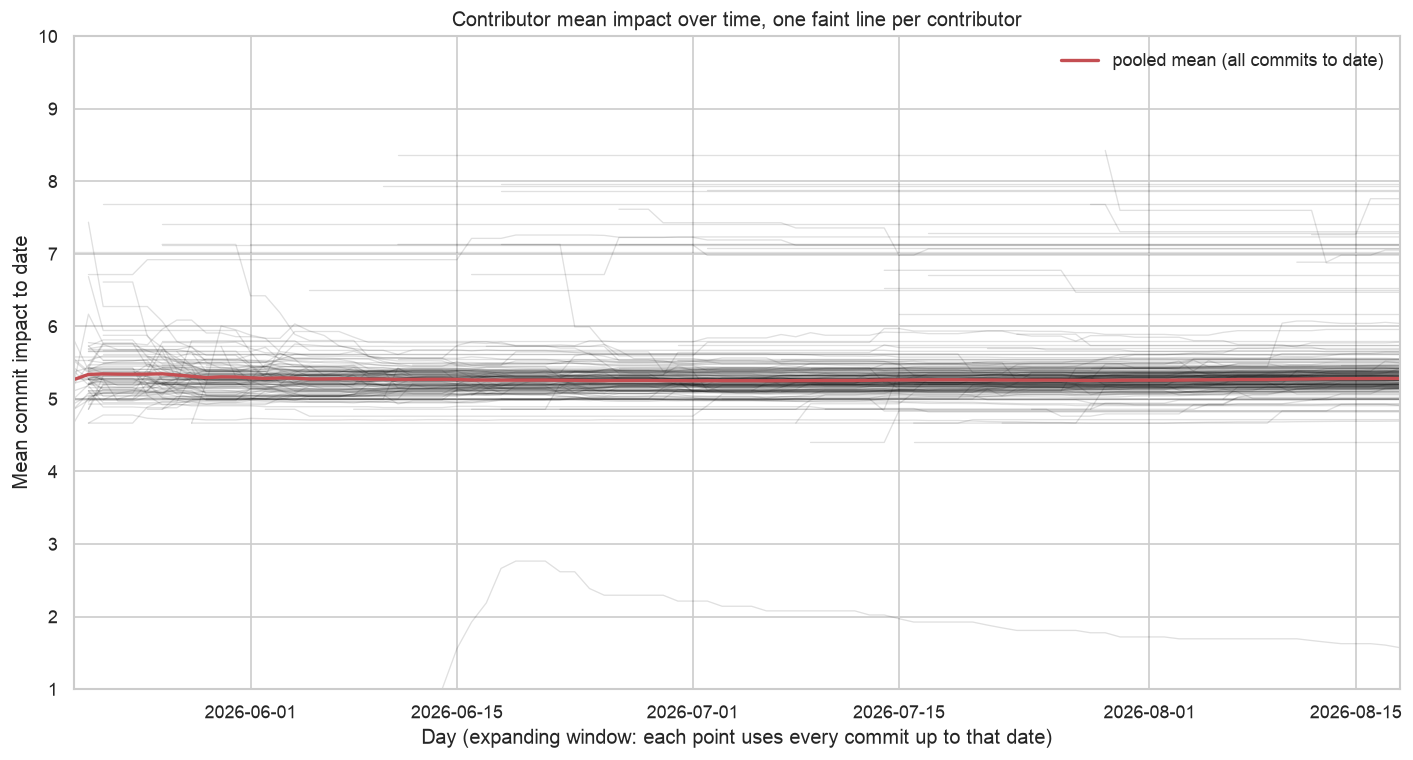

In [6]:
by_day = attributed.copy()
by_day["day"] = by_day["committed_at"].dt.normalize()
day_index = pd.date_range(by_day["day"].min(), by_day["day"].max(), freq="D", tz="UTC")

per_day = by_day.groupby(["contributor", "day"])["impact"].agg(["sum", "size"])
daily_sum = per_day["sum"].unstack("day").reindex(columns=day_index).fillna(0.0)
daily_n = per_day["size"].unstack("day").reindex(columns=day_index).fillna(0)

cum_sum = daily_sum.cumsum(axis=1)
cum_n = daily_n.cumsum(axis=1)

# Dividing by NaN (not 0) leaves days before a contributor's first commit undrawn.
cum_mean = cum_sum / cum_n.where(cum_n > 0)
pooled_mean = cum_sum.sum(axis=0) / cum_n.sum(axis=0)

final_day = cum_mean.iloc[:, -1]
assert np.allclose(final_day.reindex(order), means["mean"].to_numpy())
print(f"{len(day_index)} days: {day_index[0].date()} → {day_index[-1].date()}")
print(f"contributors active by day 1: {int((cum_n.iloc[:, 0] > 0).sum())}")
print(f"contributors active by day {len(day_index)}: {int((cum_n.iloc[:, -1] > 0).sum())}")

fig, ax = plt.subplots(figsize=(12, 6.5))
for _, row in cum_mean.iterrows():
    ax.plot(day_index, row.to_numpy(), color="black", alpha=0.12, linewidth=0.8)
ax.plot(
    day_index,
    pooled_mean.to_numpy(),
    color="#c44e52",
    linewidth=2.0,
    label="pooled mean (all commits to date)",
)
ax.set_ylim(1, 10)
ax.set_xlim(day_index[0], day_index[-1])
ax.set_xlabel("Day (expanding window: each point uses every commit up to that date)")
ax.set_ylabel("Mean commit impact to date")
ax.set_title("Contributor mean impact over time, one faint line per contributor")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()